# Extreme learning machine model for neonate clinical indicators

## 1. Import libraries

In [372]:
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, auc

## 2. Load the dataset

In [373]:
df = pd.read_csv('../../clinical_data/neonatal_processed.csv')
df.head()

,gestational_age_weeks,birth_weight_g,head_circumference_cm,delivery_mode,apgar_1min,apgar_5min,temperature_c,heart_rate_bpm,respiratory_rate_bpm,spo2_percent,primary_outcome
0,38.2,2730,37.0,0,9,10,36.7,147,48,96,0
1,39.8,2260,34.8,0,5,9,36.7,125,43,97,0
2,37.1,3030,39.4,0,9,9,36.4,120,47,97,0
3,39.7,3130,18.1,0,8,10,36.8,143,54,96,0
4,40.5,2870,34.1,0,8,7,37.2,108,46,97,0


## 3. Separate features and target variable

In [374]:
#Separate features and target variable
x = df.drop("primary_outcome", axis=1)
y = df["primary_outcome"]

## 4. Scale features

In [375]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

## 5. Train-Test Split

In [376]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

## 6. Initialize ELM parameters

In [377]:
input_size = x_train.shape[1] #number of features
hidden_neurons = 950 #number of neurons in hidden layer
output_size = 1 #binary classification

#Initialize weights
w = np.random.rand(input_size, hidden_neurons)
b = np.random.rand(output_size, hidden_neurons)

## 7. Define activation function

In [378]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

## 8. Compute hidden layer output

In [379]:
h_train = sigmoid(np.dot(x_train, w) + b)

## 9. Compute output weights (beta)

In [380]:
beta = np.dot(np.linalg.pinv(h_train), y_train)

## 10. Predict on test set

In [381]:
h_test = sigmoid(np.dot(x_test, w) + b)
y_pred_prob = np.dot(h_test, beta)
y_pred = (y_pred_prob >= 0.35).astype(int)

## 11. Evaluate performance

In [382]:
#Accuracy evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"ELM Model Accuracy: {accuracy:.4f}")

#Precision, Recall, F1-Score
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

#PR_AUC evaluation
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

ELM Model Accuracy: 0.9832
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7296
           1       0.69      0.69      0.69       204

    accuracy                           0.98      7500
   macro avg       0.84      0.84      0.84      7500
weighted avg       0.98      0.98      0.98      7500

Precision-Recall AUC: 0.7610


## 12. Evaluation visuals

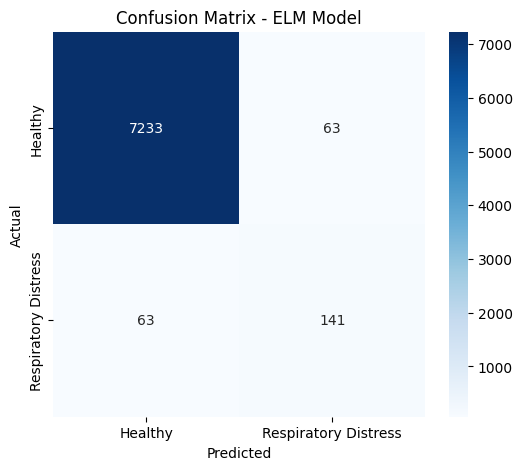

In [383]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Healthy', 'Respiratory Distress']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ELM Model')
plt.show()